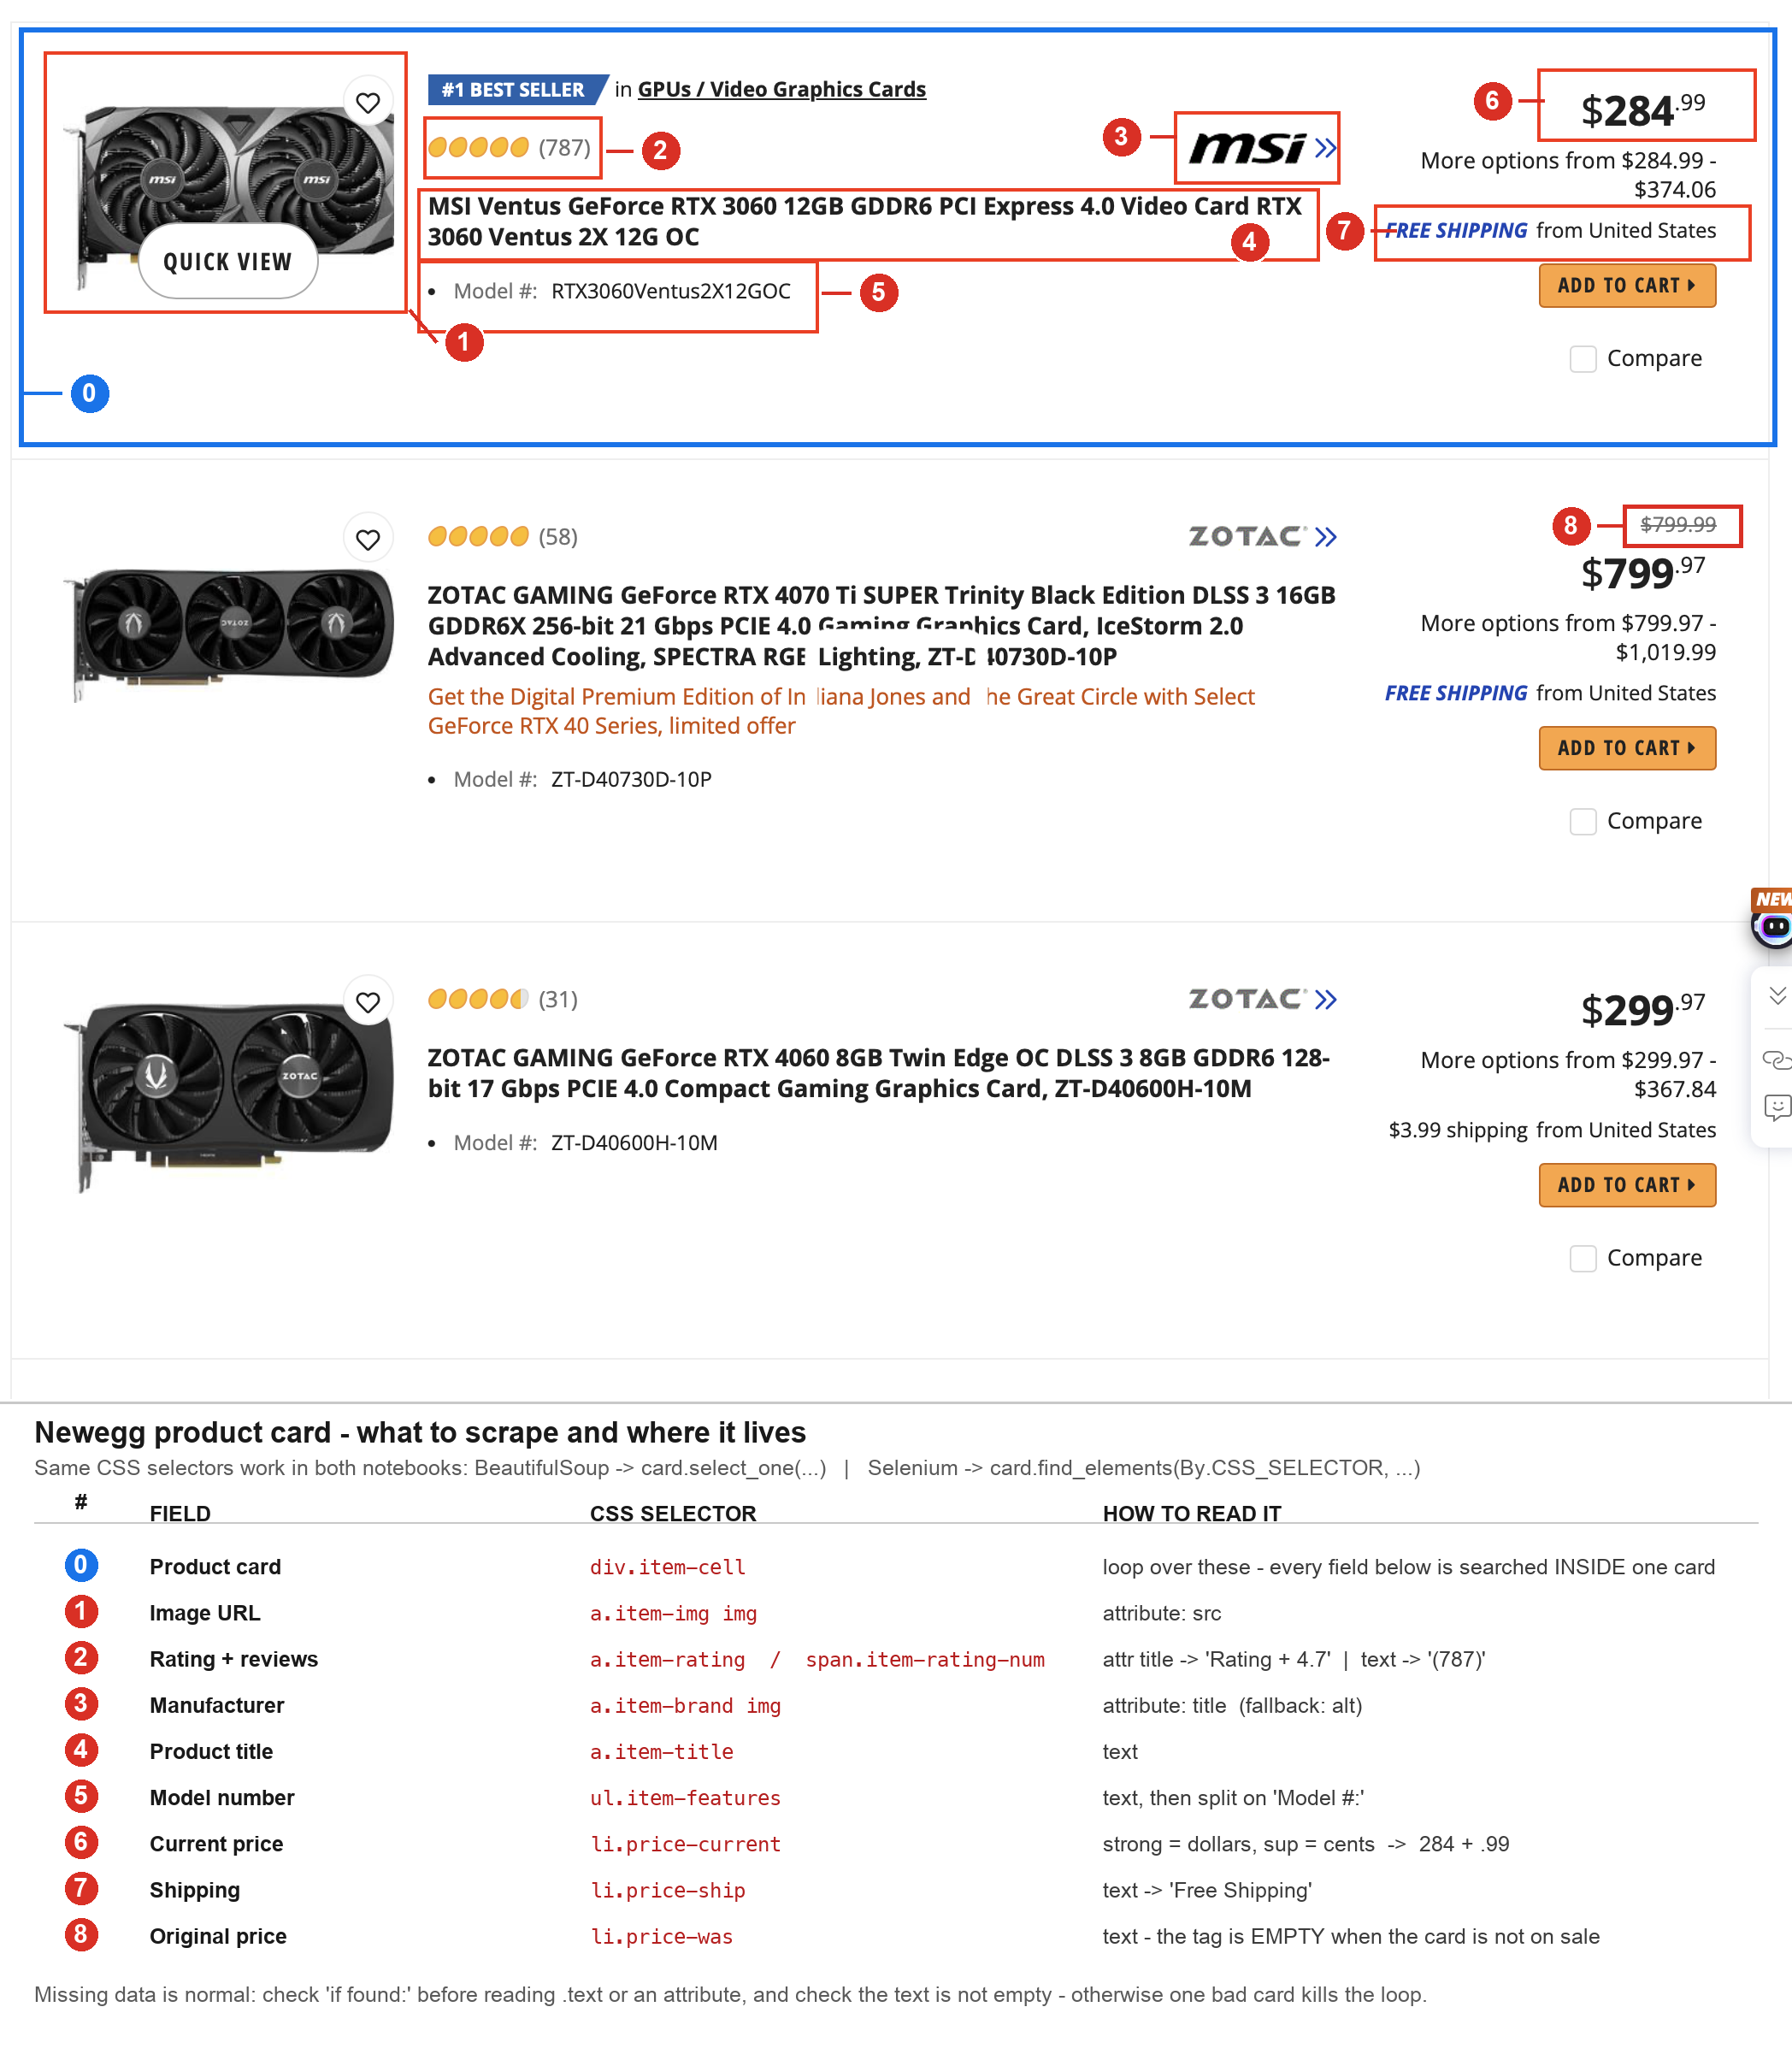

In [1]:
import time

from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import Select, WebDriverWait
from webdriver_manager.chrome import ChromeDriverManager

import pandas as pd
import selenium
from selenium import webdriver

from tqdm import tqdm

In [3]:
url = "https://www.newegg.com/Desktop-Graphics-Cards/SubCategory/ID-48"

PAGES_TO_SCRAPE = 20

service = Service(ChromeDriverManager().install())
options = Options()
options.add_argument('--headless=new')
driver = webdriver.Chrome(options=options)
driver.get(url)
time.sleep(5)

gpus = []
page = 1

while page <= PAGES_TO_SCRAPE:
    driver.get(url + '/Page-' + str(page))
    products = driver.find_elements(By.CLASS_NAME, 'item-cell')

    for product in tqdm(products, f'Page {page} in progress...'):
        img = product.find_elements(By.CLASS_NAME, 'item-img')
        if img:
            img = img[0].find_element(By.TAG_NAME, 'img').get_attribute('src')
        else:
            img = None

        rating = product.find_elements(By.CLASS_NAME, 'item-rating')
        if rating:
            rating = rating[0].get_attribute('title').split('+ ', 1)[-1]
        else:
            rating = None

        reviews = product.find_elements(By.CLASS_NAME, 'item-rating-num')
        if reviews:
            reviews = reviews[0].text
        else:
            reviews = None

        manufacturer = product.find_elements(By.CLASS_NAME, 'item-brand')
        if manufacturer:
            manufacturer = manufacturer[0].find_element(By.TAG_NAME, 'img').get_attribute('title') or manufacturer[0].find_element(By.TAG_NAME, 'img').get_attribute('alt')
        else:
            manufacturer = None

        title = product.find_elements(By.CLASS_NAME, 'item-title')[0].text
        if not title:
            continue

        model = product.find_elements(By.CLASS_NAME, 'item-features')
        if model:
            model_raw = model[0].text
            model_text = model_raw.split(': ', 1)[-1]
        else:
            model_text = None

        price = product.find_elements(By.CLASS_NAME, 'price-current')
        if price:
            price = price[0].text
        else:
            price = None

        shipping_price = product.find_elements(By.CLASS_NAME, 'price-ship')
        if shipping_price:
            shipping_price = shipping_price[0].text
        else:
            shipping_price = None

        original_price = product.find_elements(By.CLASS_NAME, 'price-was')
        if original_price:
            original_price = original_price[0].text
        else:
            original_price = None

        gpu = {
            'img': img,
            'rating': rating,
            'reviews': reviews,
            'manufacturer': manufacturer,
            'title': title,
            'model': model_text,
            'price': price,
            'shipping_price': shipping_price,
            'original_price': original_price
        }
        gpus.append(gpu)

    page+=1

time.sleep(3)
driver.quit()

df = pd.DataFrame(gpus)
df.to_csv('newegg.csv', index=False)

Page 20 in progress...: 100%|██████████████████████████████████████████████████████████| 36/36 [00:08<00:00,  4.01it/s]
